In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from os import listdir
import random
import time
import datetime
from sklearn.preprocessing import LabelEncoder

import cv2
from matplotlib.image import imread
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, auc, roc_auc_score, roc_curve, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalAveragePooling1D, Flatten, Dense, Dropout 
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import RMSprop, Adam
from plot_keras_history import show_history, plot_history

import mlflow
from mlflow.models import infer_signature
import mlflow.keras
from tensorflow.keras.callbacks import TensorBoard

In this "Place de Marché" project, we're now going to classify 1050 products, based on images into 7 categories using a deep learning model built on the CNN VGG16 architecture. We will preprocess the images, encode labels, and fine-tune a pretrained model, using transfer learning, by adding custom dense layers, dropout, and a softmax output layer. The model will be trained with early stopping and checkpointing to optimize accuracy while preventing overfitting.

In [5]:
# Load dataset
df = pd.read_csv('dataset_master.csv')
df.head(3)

,product_name,image,description,_main_cat
0,Elegance Polyester Multicolor Abstract Eyelet ...,55b85ea15a1536d46b7190ad6fff8ce7.jpg,Key Features of Elegance Polyester Multicolor ...,Home Furnishing
1,Sathiyas Cotton Bath Towel,7b72c92c2f6c40268628ec5f14c6d590.jpg,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care
2,Eurospa Cotton Terry Face Towel Set,64d5d4a258243731dc7bbb1eef49ad74.jpg,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care


In [7]:
df.shape

(1050, 4)

# Prepare images before CNN processing

In [10]:
image_path = 'Flipkart/Images/'

# Store all images in a list
list_image = listdir(image_path)

# Verify number of images
len(list_image)

1050

Image category : Kitchen & Dining


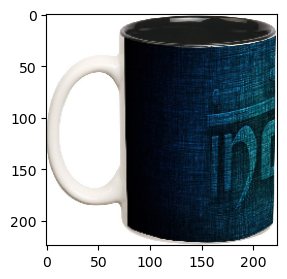

In [12]:
# Dsiplay a random image
random_pic = random.randint(0, len(list_image) - 1)
image_file_name = df.loc[random_pic, 'image']

print("Image category :", df.loc[random_pic, '_main_cat'])
plt.figure(figsize=(3, 3))
img = load_img(image_path + image_file_name, target_size=(224, 224))
plt.imshow(img)
plt.show()

In [14]:
# Prepare the images before VGG-16 processing
prepared_images = []

# Start timer
start_time = time.time()

for image_num in range(df.shape[0]) :
    # Display progress status every 100 images
    if image_num % 100 == 0: print(f'processing image {image_num}')
    # Load and preprocess the image
    img = load_img(image_path + df['image'][image_num], target_size=(224, 224))
    img = img_to_array(img)
    img = preprocess_input(img)
    prepared_images.append(img)

# Convert the list of images to a NumPy array
prepared_images_np = np.array(prepared_images)

# End timer
end_time = time.time()
print(f'Prepared images array shape {prepared_images_np.shape}')
print(f'Time taken: {end_time - start_time:.2f} seconds')

processing image 0
processing image 100
processing image 200
processing image 300
processing image 400
processing image 500
processing image 600


C:\Users\OmenH\anaconda3\Lib\site-packages\PIL\Image.py:3186: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


processing image 700
processing image 800
processing image 900
processing image 1000
Prepared images array shape (1050, 224, 224, 3)
Time taken: 18.18 seconds


In [15]:
# Prepare train set, validation set and test set
test_size = 100

# Train-validation set
X = prepared_images_np[test_size:]

# Convert string labels to integer codes
label_encoder = LabelEncoder()
integer_encoded = label_encoder.fit_transform(df['_main_cat'])

# Convert integer codes to Keras one-hot encoding
y_keras = to_categorical(integer_encoded)
y = y_keras[test_size:]

# Test set
X_test = prepared_images_np[:test_size]
y_test = y_keras[:test_size]

# Display and verify sets sizes
print(f'Train and validation set size : {X.shape[0]}')
print(f'Test set size : {X_test.shape[0]}')

Train and validation set size : 950
Test set size : 100


In [16]:
# Display the correspondence between categories and columns
categories = label_encoder.classes_
print("Correspondence of categories with columns:")
for i, category in enumerate(categories):
    print(f"Colonne {i} : {category}")

Correspondence of categories with columns:
Colonne 0 : Baby Care
Colonne 1 : Beauty and Personal Care
Colonne 2 : Computers
Colonne 3 : Home Decor & Festive Needs
Colonne 4 : Home Furnishing
Colonne 5 : Kitchen & Dining
Colonne 6 : Watches


# MLFlow & TensorBoard initialization

Execute the command in Anaconda command prompt to run the MLFlow server on a local machine :

mlflow server --host 127.0.0.1 --port 5000

access : http://localhost:5000

In [23]:
# Connect to the mlflow local server
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [25]:
# Create a new MLflow Experiment
mlflow.set_experiment("CNN_improved_VIT")

<Experiment: artifact_location='mlflow-artifacts:/525763610983704836', creation_time=1747917847727, experiment_id='525763610983704836', last_update_time=1747917847727, lifecycle_stage='active', name='CNN_improved_VIT', tags={}>

Execute the command in Anaconda command prompt to run the TensorBoard server on a local machine :

tensorboard --logdir=./logs

access : http://localhost:6006/

In [80]:
# Generate a timestamped folder to separate each run
log_dir = "./logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S_baseline")

# TensorBoard callback
tensorboard_callback = TensorBoard(log_dir=log_dir)

# Configure and train customized VGG-16 model

In [42]:
# Start from a VGG-16 pre-trained model, without the top layer
model0 = VGG16(include_top=False, weights="imagenet", input_shape=(224, 224, 3))

# Set layers to be non-trainable
for layer in model0.layers:
    layer.trainable = False

# Get the output of the above model
x = model0.output

# Add a pooling to reduce the output shape to 512
x = GlobalAveragePooling2D()(x)

# Add a fully connected layer with shape 256 and ReLU activation
x = Dense(256, activation='relu')(x)

# Add a dropout layer to prevent overfitting
x = Dropout(0.5)(x)
#x = Dropout(0.6)(x)

# Add the output layer with 7 units classes for the "Place du Marché" 7 categories
predictions = Dense(7, activation='softmax')(x)

# Define the new model
model = Model(inputs=model0.input, outputs=predictions)

# Create an optimizer with the new learning rate
new_learning_rate = 0.001  # try 0.0001, 0.001, 0.05
#optimizer = RMSprop(learning_rate=new_learning_rate)
optimizer = Adam(learning_rate=new_learning_rate)

# Compile the model
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,3

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


rem :

The Dropout layer helps prevent overfitting by randomly setting a fraction of the input units to zero during training. This forces the model to learn more robust features rather than relying on specific neurons, improving generalization on unseen data. The Dropout(0.5) means that 50% of the neurons in that layer will be disabled during each training step.

The "categorical_crossentropy" loss function is suitable for multi-class classification problems where the target labels are one-hot encoded.

Adam and RMSprop are suitable optimizers for training deep CNNs like VGG16.

The n-2 dense layer has (512 + 1) x 256 = 131328 parameters

The output has (256 + 1) x 7 = 1799 parameters

As a consequence, 131328 + 1799 = 133127 parameters must be trained

In [45]:
# Separate train set and validation test
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)
print(f'Train set shape : {X_train.shape}')
print(f'Validation set shape : {X_val.shape}')

Train set shape : (760, 224, 224, 3)
Validation set shape : (190, 224, 224, 3)


In [46]:
# Verify target is balanced
y_val.sum(axis=0)

array([28., 27., 29., 27., 28., 27., 24.])

We set up callbacks :
 - ModelCheckpoint => This callback is used to save the model's weights at certain points during training.
 - EarlyStopping => This callback is used to stop training when a monitored metric has stopped improving for a given number of epochs (patience hyperparameter).

In [50]:
# Creation of callbacks
model1_save_path = "./model1_baseline_best_weights.h5.keras"

# Callback
checkpoint = ModelCheckpoint(model1_save_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# Early Stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

callbacks_list = [checkpoint, es, tensorboard_callback]

In [52]:
optimizer.__class__.__name__

'Adam'

In [85]:
#Start MLFlow logging
with mlflow.start_run(run_name="Adam customized VGG-16"):
    
    # Log hyperparameters
    mlflow.log_params({
        "learning_rate": new_learning_rate,
        "optimizer": optimizer.__class__.__name__,
        "batch_size": 64,
        "epochs": 20  #30
    })
    
    # Training model
    history1 = model.fit(X_train, y_train, epochs=30, batch_size=64,
                      callbacks=callbacks_list, validation_data=(X_val, y_val),
                      verbose=1)

    # Evaluating the model after loading the best weights
    model.load_weights(model1_save_path)
    
    # Log final training, validation and test accuracy et loss metrics
    print()
    loss_train, accuracy_train = model.evaluate(X_train, y_train, verbose=True)
    print(f'Train Accuracy :  {accuracy_train:.4f} - Train loss {loss_train:.4f}')

    print()
    loss_validation, accuracy_validation = model.evaluate(X_val, y_val, verbose=True)
    print(f'\nValidation Accuracy :  {accuracy_validation:.4f} - Validation loss {loss_validation:.4f}')

    print()
    loss_test, accuracy_test = model.evaluate(X_test, y_test, verbose=True)
    print(f'\nTest Accuracy :  {accuracy_test:.4f} - Test loss {loss_test:.4f}')

    mlflow.log_metrics({
        "train_accuracy": accuracy_train,
        "train_loss": loss_train,
        "val_accuracy_best": accuracy_validation,
        "val_loss_best": loss_validation,
        "test_accuracy": accuracy_test,        
        "test_loss": loss_test
    })

    # Infer the model signature (not mandatory)
    sample_input = np.expand_dims(X_train[0], axis=0)  # Ensure batch dimension (1, 224, 224, 3)
    sample_output = model.predict(sample_input)  # Get the model's output format
    signature = infer_signature(sample_input, sample_output)
    
    # Log the best trained model
    mlflow.keras.log_model(model, "customized_VGG16_best_model", signature=signature)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2706 - loss: 8.5230
Epoch 1: val_loss improved from inf to 1.65088, saving model to ./model1_baseline_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 60s 5s/step - accuracy: 0.2799 - loss: 8.3293 - val_accuracy: 0.7316 - val_loss: 1.6509
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6917 - loss: 2.0203
Epoch 2: val_loss improved from 1.65088 to 1.34323, saving model to ./model1_baseline_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.6946 - loss: 2.0024 - val_accuracy: 0.7474 - val_loss: 1.3432
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7958 - loss: 1.0988
Epoch 3: val_loss improved from 1.34323 to 1.26142, saving model to ./model1_baseline_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.7955 - loss: 1.0949 - val_accuracy: 0.7737 - val_loss: 1.2614
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8240 - loss: 0.9018
Epo

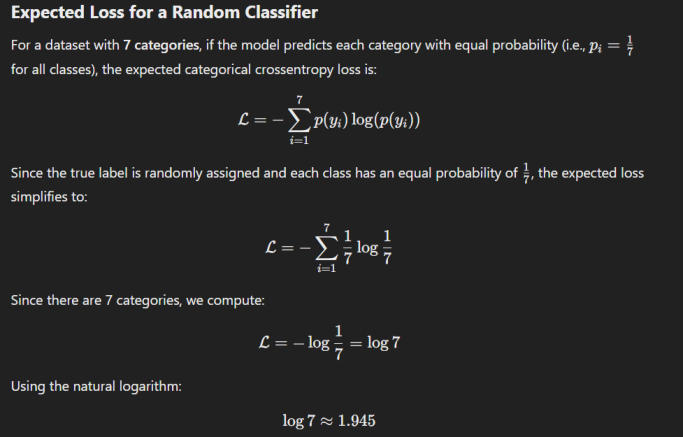

rem : natural logarithm

In [88]:
#Summary training, validation and test accuracy et loss metrics
print(f'Train Accuracy :  {accuracy_train:.4f} - Train loss {loss_train:.4f}')
print(f'Validation Accuracy :  {accuracy_validation:.4f} - Validation loss {loss_validation:.4f}')
print(f'Test Accuracy :  {accuracy_test:.4f} - Test loss {loss_test:.4f}')

Train Accuracy :  0.9974 - Train loss 0.0164
Validation Accuracy :  0.8053 - Validation loss 1.0027
Test Accuracy :  0.7900 - Test loss 2.0053


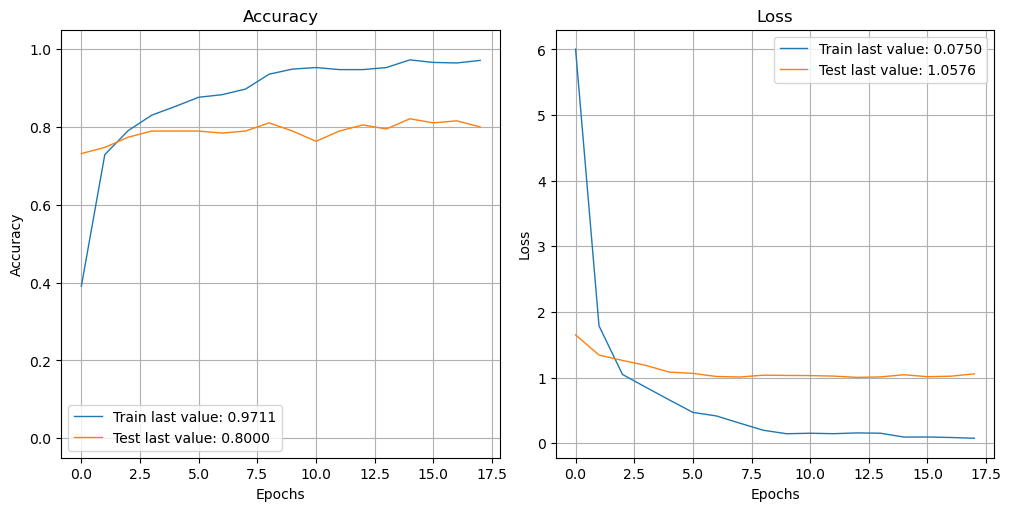

In [90]:
# Visualization the training history of
show_history(history1)
plt.close()

rem : the graph display results on  train and validation sets (not test set).

ccl : There is a huge gap between the train accuracy and validation accuracy, showing that the model clearly overfits.

rem : Others tests have been done

 - train_test_split 75/25
 - batch size decreased to 50 instead of 64 + train_test_split 82/18 : no real improvment
 - batch size increased to 128 instead of 64 + train_test_split 80/20 : ko (memory issue)
 - Change dropout ratio 0.6 instead of 0.5
 - Adam vs RMSprop optimizer

rem : Decreasing the dropout layer ratio from 0.5 to 0.6 helps the model to slow down and reduce the overfitting, but the accuracy is reduced.

# Data augmentation

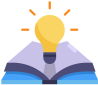

Data augmentation is a technique used to artificially increase the diversity of a training dataset by applying random transformations to the images. This helps improve the model's ability to generalize and reduces overfitting, especially when working with limited data.

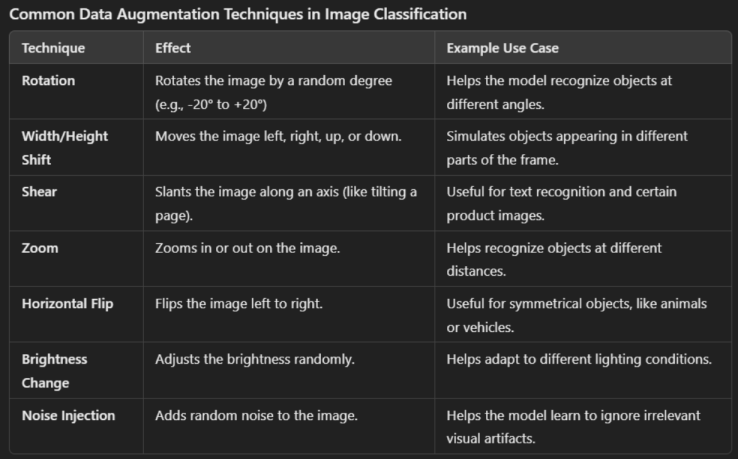

In [54]:
# Create an ImageDataGenerator with augmentations
datagen = ImageDataGenerator(
    rotation_range=20,       # Rotate images by up to 20 degrees
    width_shift_range=0.2,   # Shift width by up to 20% of image width
    height_shift_range=0.2,  # Shift height by up to 20% of image height
    shear_range=0.2,         # Shear angle up to 20 degrees
    zoom_range=0.2,          # Randomly zoom in/out by up to 20%
    horizontal_flip=True,    # Flip images horizontally
    fill_mode='nearest'      # Fill missing pixels with the nearest pixel
)

# Apply augmentation to the training set
train_generator = datagen.flow(X_train, y_train, batch_size=64)

In [56]:
# TensorBoard configuration
log_dir = "./logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S_data_augmentation")

# TensorBoard callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,             # where to store the logs
    histogram_freq=1,            # to record histograms (useful for deep networks)
    write_graph=True,            # to visualize the model architecture
    write_images=True,           # optional: saves model weights as images
)

In [58]:
# Creation of callback
model2_save_path = "./model_data_augmentation_best_weights.h5.keras"

# Callback
checkpoint = ModelCheckpoint(model2_save_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# Early Stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

callbacks_list = [checkpoint, es, tensorboard_callback]

In [106]:
# Hyperparameter checking
print(f'Learning rate : {new_learning_rate}')
print(f'Optimizer : {optimizer.__class__.__name__}')

Learning rate : 0.001
Optimizer : Adam


In [107]:
#Start new MLFlow logging
with mlflow.start_run(run_name="Data_augmentation_VGG-16"):
    
    # Log hyperparameters
    mlflow.log_params({
        "learning_rate": new_learning_rate,
        "optimizer": optimizer.__class__.__name__,
        "batch_size": 64,
        "epochs": 30
    })
    
    # Training model
    history2 = model.fit(train_generator, epochs=30, #batch_size=64,
                      callbacks=callbacks_list, validation_data=(X_val, y_val),
                      verbose=1)    

    # Evaluating the model after loading the best weights
    model.load_weights(model2_save_path)
    
    # Log final training, validation and test accuracy et loss metrics
    print()
    print('############## MODEL METRICS ##############')
    loss_train, accuracy_train = model.evaluate(X_train, y_train, verbose=True)
    print(f'Train Accuracy :  {accuracy_train:.4f} - Train loss {loss_train:.4f}')

    print()
    loss_validation, accuracy_validation = model.evaluate(X_val, y_val, verbose=True)
    print(f'\nValidation Accuracy :  {accuracy_validation:.4f} - Validation loss {loss_validation:.4f}')

    print()
    loss_test, accuracy_test = model.evaluate(X_test, y_test, verbose=True)
    print(f'\nTest Accuracy :  {accuracy_test:.4f} - Test loss {loss_test:.4f}')

    mlflow.log_metrics({
        "train_accuracy": accuracy_train,
        "train_loss": loss_train,
        "val_accuracy_best": accuracy_validation,
        "val_loss_best": loss_validation,
        "test_accuracy": accuracy_test,        
        "test_loss": loss_test
    })

    # Infer the model signature
    sample_input = np.expand_dims(X_train[0], axis=0)  # Ensure batch dimension (1, 224, 224, 3)
    sample_output = model.predict(sample_input)  # Get the model's output format
    signature = infer_signature(sample_input, sample_output)
    
    # Log the best trained model
    mlflow.keras.log_model(model, "Data_augmentation_VGG16_best_model", signature=signature)

C:\Users\OmenH\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8639 - loss: 0.4253
Epoch 1: val_loss improved from inf to 1.02772, saving model to ./model_data_augmentation_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step - accuracy: 0.8641 - loss: 0.4244 - val_accuracy: 0.7895 - val_loss: 1.0277
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8787 - loss: 0.3634
Epoch 2: val_loss did not improve from 1.02772
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.8788 - loss: 0.3641 - val_accuracy: 0.7895 - val_loss: 1.0765
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8664 - loss: 0.3431
Epoch 3: val_loss did not improve from 1.02772
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.8671 - loss: 0.3431 - val_accuracy: 0.7842 - val_loss: 1.0597
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8988 - loss: 0.3068
Epoch 4: val_loss did not improve from 1.02772
12/12 ━━━━━━━━━━━━━━━━━━━━ 53s 4s/step - accuracy: 0.8983 - loss: 0.30

In [109]:
#Summary training, validation and test accuracy et loss metrics
print(f'Train Accuracy :  {accuracy_train:.4f} - Train loss {loss_train:.4f}')
print(f'Validation Accuracy :  {accuracy_validation:.4f} - Validation loss {loss_validation:.4f}')
print(f'Test Accuracy :  {accuracy_test:.4f} - Test loss {loss_test:.4f}')

Train Accuracy :  0.9974 - Train loss 0.0192
Validation Accuracy :  0.7895 - Validation loss 1.0277
Test Accuracy :  0.7900 - Test loss 1.8879


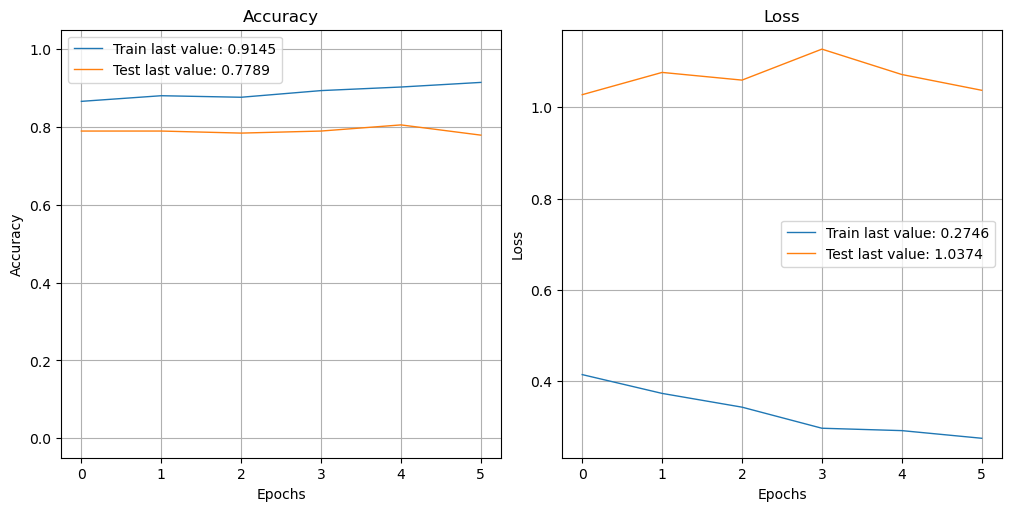

In [110]:
show_history(history2)
plt.close()

rem : the graph display results on train and validation sets (not test set).

ccl : The model is more robust. As a matter of fact the difference between train and validation accuracy is silghtly lower than without data augmentation. The test accuracy hasn't been improved.

# Adding another Dropout layer

Out of curiosity and in order to endeavor to reduce the remaining overfitting, the customized VGG-16 model may be improved adding a Dropout layer, between the Pooling and dense layers. Let's find out if the model can be improved.

In [60]:
# Start from a VGG-16 pre-trained model, without the top layer
model0 = VGG16(include_top=False, weights="imagenet", input_shape=(224, 224, 3))

# Set layers to be non-trainable
for layer in model0.layers:
    layer.trainable = False

# Get the output of the above model
x = model0.output

# Add a pooling to reduce the output shape to 512
x = GlobalAveragePooling2D()(x)

# Add another dropout layer before the output
x = Dropout(0.4)(x)

# Add a fully connected layer with shape 256 and ReLU activation
x = Dense(256, activation='relu')(x)

# Add a dropout layer to prevent overfitting
x = Dropout(0.4)(x)

# Add the output layer with 7 units classes for the "Place du Marché" 7 categories
predictions = Dense(7, activation='softmax')(x)

# Define the new model
model = Model(inputs=model0.input, outputs=predictions)

# Create an optimizer with the new learning rate
new_learning_rate = 0.001  # try 0.0001, 0.001, 0.05
#optimizer = RMSprop(learning_rate=new_learning_rate)
optimizer = Adam(learning_rate=new_learning_rate)

# Compile the model
#model.compile(loss="categorical_crossentropy", optimizer='rmsprop', metrics=["accuracy"])
model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │              

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

None


In [62]:
# TensorBoard configuration
log_dir = "./logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S_data_aug_add_dropout")

# TensorBoard callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,             # where to store the logs
    histogram_freq=1,            # to record histograms (useful for deep networks)
    write_graph=True             # to visualize the model architecture
)

In [64]:
# Creation of callback
model3_save_path = "./model3_add_dropout_best_weights.h5.keras"

# Callback
checkpoint = ModelCheckpoint(model3_save_path, monitor='val_loss', verbose=1, save_best_only=True, mode='min')

# Early Stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

callbacks_list = [checkpoint, es, tensorboard_callback]

In [66]:
# Hyperparameter checking
print(f'Learning rate : {new_learning_rate}')
print(f'Optimizer : {optimizer.__class__.__name__}')

Learning rate : 0.001
Optimizer : Adam


In [68]:
#Start new MLFlow logging
with mlflow.start_run(run_name="Add_Dropout_layer_Data_augm_VGG-16"):
    
    # Log hyperparameters
    mlflow.log_params({
        "learning_rate": new_learning_rate,
        "optimizer": optimizer.__class__.__name__,
        "batch_size": 64,
        "epochs": 30
    })
    
    # Training model
    history3 = model.fit(train_generator, epochs=30, #batch_size=64,
                      callbacks=callbacks_list, validation_data=(X_val, y_val),
                      verbose=1)

    # Evaluating the model after loading the best weights
    model.load_weights(model3_save_path)
    
    # Log final training, validation and test accuracy et loss metrics
    print()
    print('############## MODEL METRICS ##############')
    loss_train, accuracy_train = model.evaluate(X_train, y_train, verbose=True)
    print(f'Train Accuracy :  {accuracy_train:.4f} - Train loss {loss_train:.4f}')

    print()
    loss_validation, accuracy_validation = model.evaluate(X_val, y_val, verbose=True)
    print(f'\nValidation Accuracy :  {accuracy_validation:.4f} - Validation loss {loss_validation:.4f}')

    print()
    loss_test, accuracy_test = model.evaluate(X_test, y_test, verbose=True)
    print(f'\nTest Accuracy :  {accuracy_test:.4f} - Test loss {loss_test:.4f}')

    mlflow.log_metrics({
        "train_accuracy": accuracy_train,
        "train_loss": loss_train,
        "val_accuracy_best": accuracy_validation,
        "val_loss_best": loss_validation,
        "test_accuracy": accuracy_test,        
        "test_loss": loss_test
    })

    # Log training history (metrics for each epoch) (rem : autolog() method exists)
    for epoch in range(len(history3.history["loss"])):
        mlflow.log_metric("train_loss_epoch", history3.history["loss"][epoch], step=epoch)
        mlflow.log_metric("val_loss_epoch", history3.history["val_loss"][epoch], step=epoch)
        mlflow.log_metric("train_accuracy_epoch", history3.history["accuracy"][epoch], step=epoch)
        mlflow.log_metric("val_accuracy_epoch", history3.history["val_accuracy"][epoch], step=epoch)

    # Infer the model signature (not mandatory)
    sample_input = np.expand_dims(X_train[0], axis=0)  # Ensure batch dimension (1, 224, 224, 3)
    sample_output = model.predict(sample_input)  # Get the model's output format
    signature = infer_signature(sample_input, sample_output)
    
    # Log the best trained model
    mlflow.keras.log_model(model, "Data_aug_add_dropout_VGG16_best_model", signature=signature)

C:\Users\OmenH\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1611 - loss: 11.4429
Epoch 1: val_loss improved from inf to 2.21183, saving model to ./model3_add_dropout_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 55s 4s/step - accuracy: 0.1675 - loss: 11.2441 - val_accuracy: 0.6158 - val_loss: 2.2118
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4388 - loss: 4.3626
Epoch 2: val_loss improved from 2.21183 to 1.38369, saving model to ./model3_add_dropout_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.4424 - loss: 4.3158 - val_accuracy: 0.7474 - val_loss: 1.3837
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5982 - loss: 2.4323
Epoch 3: val_loss improved from 1.38369 to 1.33949, saving model to ./model3_add_dropout_best_weights.h5.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step - accuracy: 0.5995 - loss: 2.4327 - val_accuracy: 0.7737 - val_loss: 1.3395
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6392 - loss:

rem : It's possible to automatically log the training history in MFlow using an auto-log fonction. This is a more efficient method that allows to follow the training directly in MLFlow. Pytorch also enable easy MLFlow logging.

In [70]:
#Summary training, validation and test accuracy et loss metrics
print(f'Train Accuracy :  {accuracy_train:.4f} - Train loss {loss_train:.4f}')
print(f'Validation Accuracy :  {accuracy_validation:.4f} - Validation loss {loss_validation:.4f}')
print(f'Test Accuracy :  {accuracy_test:.4f} - Test loss {loss_test:.4f}')

Train Accuracy :  0.9592 - Train loss 0.1738
Validation Accuracy :  0.8105 - Validation loss 0.7288
Test Accuracy :  0.7900 - Test loss 0.9391


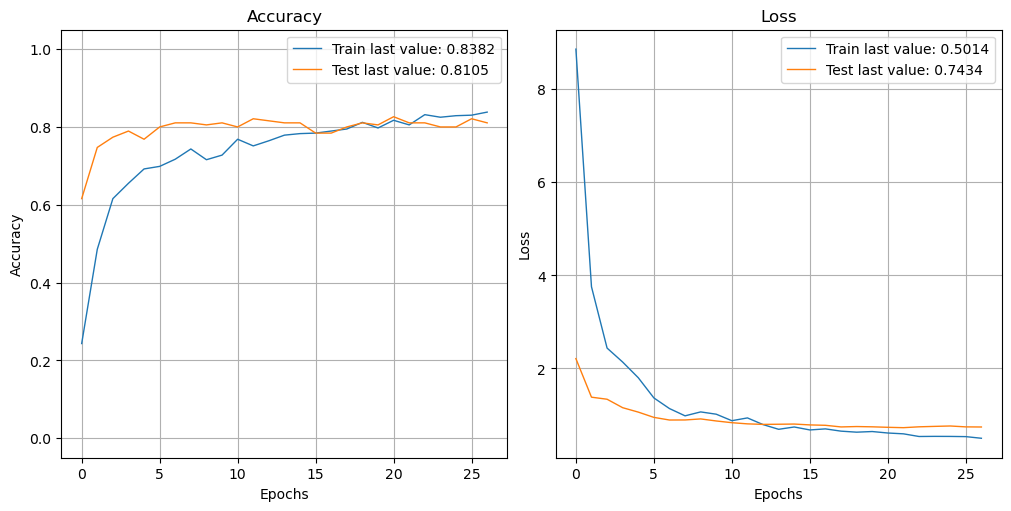

In [71]:
show_history(history3)
plt.close()

rem : the graph display results on train and validation sets (not test set).

rem : The model is very sensitive to the ratio of the 2 Dropout layers. Different tests have been run to optimize the Dropout layers ratios (convergence time VS loss function).

ccl : Because of the additional Dropout layer, the model takes more time to converge. The overfitting is reduced during training, as shown in the history graph above. However the final measured accuracy still indicates a remaining overfitting. The model performs very well on the training data but struggles to generalize to unseen data. Nevertheless considering the small size and the very important diversity and variety of the images batch, the 0.79 accuracy on the test can be considered quite good.

# Summary of results

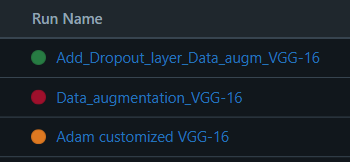

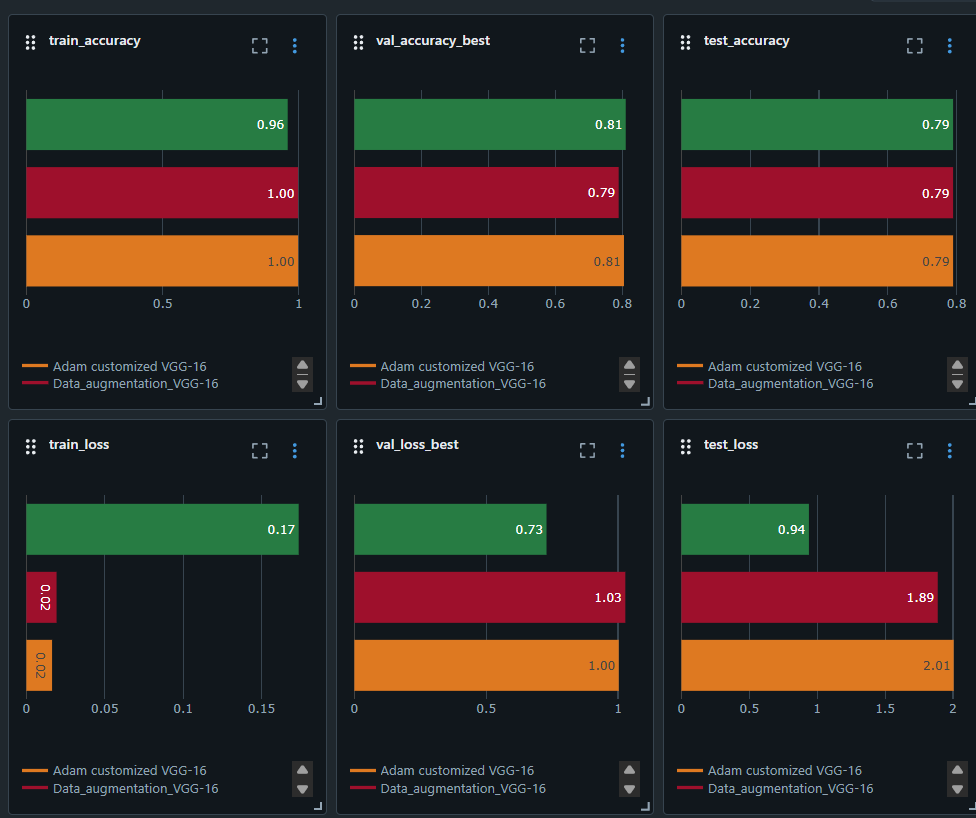

SUMMARY from previous experience

Customized VGG-16 without data augmentation : The model clearly overfits.
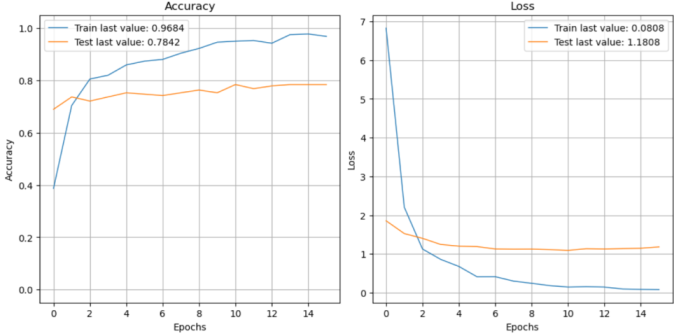
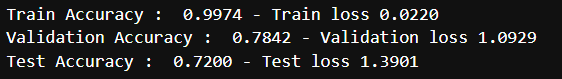


Customized VGG-16 with data augmentation : The model is more robust but still overfits. Improved test accuracy.
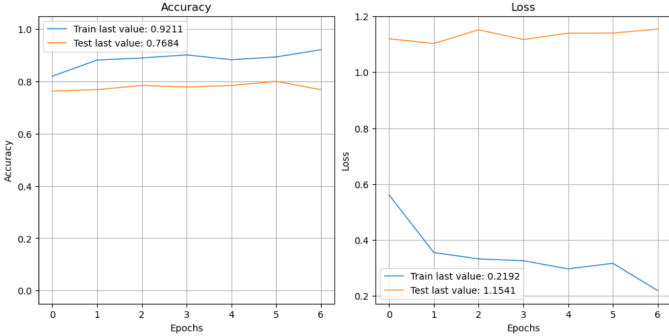
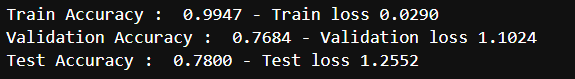


Customized VGG-16 with data augmentation and an additional Dropout layer : Less overfitting. Good mutual convergence during training. Good test accuracy.
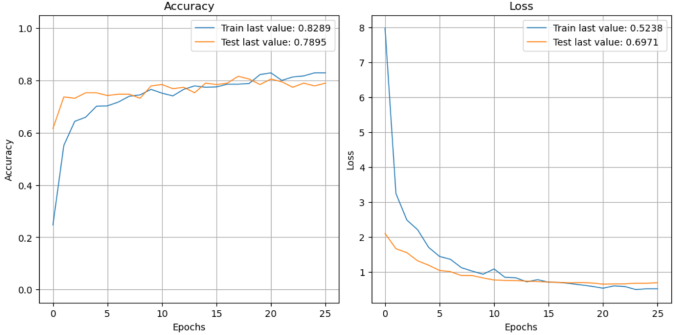
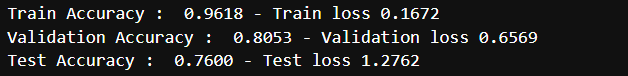

The overfitting of the model can be explained by the small dataset size (1050 images) compared to the very large number of trainable parameters (133127), meaning that on average every image is associated with roughly 127 "dedicated" neurones ! As a consequence, the model memorizes the training data rather than generalizing to unseen examples.

The data augmentation improves the model by adding different transformation to the images in input. It allows the model to learn more robust features and improve its generalization capabilities. However, overfitting still persists.

Finally the additional Dropout layer significantly reduced the overfitting randomly deactiveting neurons during training to avoid to much specialization. This led to a better balance between training and validation performance.

Tracks to explore : The customized 256 neurons dense layer seems to be oversized. Reducing the number of neurons would significantly decrease the number of trainable parameters and therefore the overfitting of the model, together with the processing time. The parameters of this layer amount to (512 + 1) x 256. Dividing by 2 the number of neurons would reduce by 2 the trainable parameters of this layer. Reducing the size of this neuron layer might perhaps make the additional Dropout unnecessary.

# Test best model loaded from MLFlow

In order to benchmark models a test procedure is defined (Accuracy, macro F1 score,classification report, confusion matrix, inference time).

The best model among all that have been tested can be loaded from MLFlow using the Run ID.

In [120]:
# Define the best Run ID
best_run_id = "e01a5637d09043f78e91c1b316215352"

# Construct the model URI
model_uri = f"runs:/{best_run_id}/customized_VGG16_best_model"

# Load the model
best_model = mlflow.keras.load_model(model_uri)

print("Best model loaded successfully!")

Best model loaded successfully!


Make Predictions Using the Loaded Model

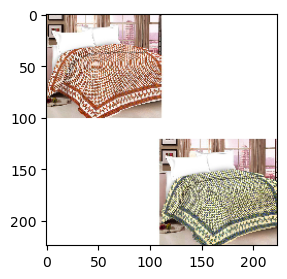

In [123]:
# Test the best VGG-16 model on the random image
random_pic = random.randint(0, len(list_image) - 1)
image_file_name = df.loc[random_pic, 'image']

# Display the image
plt.figure(figsize=(3, 3))
img = load_img(image_path + image_file_name, target_size=(224, 224))
plt.imshow(img)

plt.show()

In [124]:
# Make a single inference
start_time = time.time()
    
# convert image to the expect VGG-16 format
img = img_to_array(img)
img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))

# Pre-process the image to match VGG-16 input requirement
img = preprocess_input(img)

# VGG-16 processing
prediction = best_model.predict(img)
predicted_class = np.argmax(prediction, axis=1)

end_time = time.time()
print("Predicted class:", predicted_class[0])
print(f"Inference processing time: {end_time - start_time:.4f} seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
Predicted class: 4
Inference processing time: 0.7532 seconds


In [125]:
# Display the correspondence between categories and columns
categories = label_encoder.classes_
print("Correspondence of categories with columns:")
for i, category in enumerate(categories):
    print(f"Colonne {i} : {category}")

Correspondence of categories with columns:
Colonne 0 : Baby Care
Colonne 1 : Beauty and Personal Care
Colonne 2 : Computers
Colonne 3 : Home Decor & Festive Needs
Colonne 4 : Home Furnishing
Colonne 5 : Kitchen & Dining
Colonne 6 : Watches


Let's try with a new unknown picture : my watch

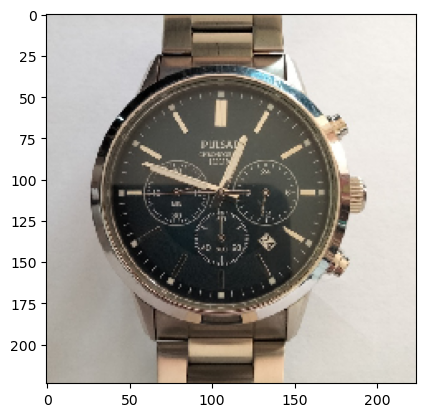

In [99]:
img = load_img('my_watch.jpg', target_size=(224, 224))
plt.imshow(img)
plt.show()

In [101]:
# convert image to the expect VGG-16 format
img = img_to_array(img)
img = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))

# Pre-process the image to match VGG-16 input requirement
img = preprocess_input(img)

# VGG-16 processing
prediction = best_model.predict(img)
predicted_class = np.argmax(prediction, axis=1)
print("Predicted class:", categories[predicted_class[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Predicted class: Watches


In [133]:
X_test.shape

(100, 224, 224, 3)

Let's perform a battery of tests in order to comparer different models. The same tests, in the same conditions will be run on other models. The tests are run on the same test set containing the 100 first pictures.

In [174]:
# Get predicted probabilities
y_pred_probs = best_model.predict(X_test)

# Get predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1) 

# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=categories))

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step
Classification Report:

                            precision    recall  f1-score   support

                 Baby Care       0.67      0.50      0.57        12
  Beauty and Personal Care       0.62      0.62      0.62        13
                 Computers       0.60      1.00      0.75         6
Home Decor & Festive Needs       1.00      0.79      0.88        14
           Home Furnishing       0.58      0.92      0.71        12
          Kitchen & Dining       0.93      0.87      0.90        15
                   Watches       1.00      0.86      0.92        28

                  accuracy                           0.79       100
                 macro avg       0.77      0.79      0.76       100
              weighted avg       0.82      0.79      0.79       100



The F1 score is a metric that combines precision and recall into a single number to give a balanced view of a model’s performance, especially in classification tasks. It's the harmonic mean of precision and recall.

The macro F1 score is the unweighted average of the F1 scores for each class in a classification problem. It treats all classes equally, regardless of how many samples each class has.

In [184]:
# Verify macro F1 score
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
macro_f1

0.7637313219118401

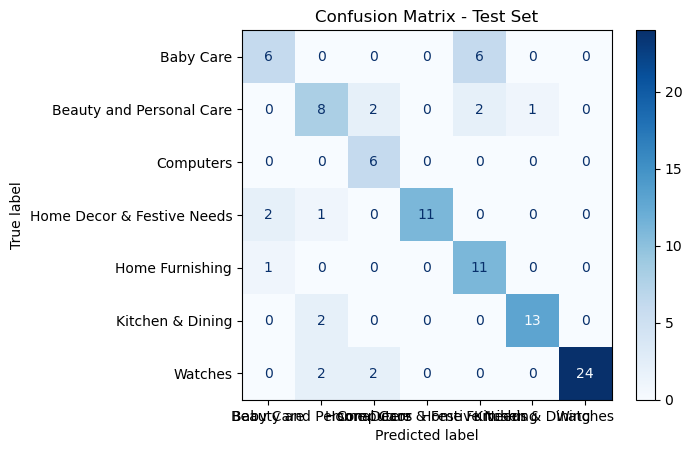

In [186]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

In [197]:
# Inference time for a single image
image = np.expand_dims(X_test[0], axis=0)

start = time.time()
_ = model.predict(image)
end = time.time()

print(f"Inference time (1 image) : {end - start:.4f} seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Inference time (1 image) : 0.2090 seconds


In [199]:
# Inference time for a 32 images batch
batch = X_test[:32]

start = time.time()
_ = model.predict(batch)
end = time.time()

print(f"Inference time (32 images batch) : {end - start:.4f} seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Inference time (32 images batch) : 1.8898 seconds
